In [ ]:
import os, shutil, random, yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

OK


In [1]:
DATA_DIR    = "detection_data"
MODEL_SIZE  = "yolov8n" 
EPOCHS      = 100
IMG_SIZE    = 1280
BATCH_SIZE  = 2            
VAL_SPLIT   = 0.25          
DEVICE      = 0   

In [5]:
# Читаем классы из classes.txt
classes_file = Path(DATA_DIR) / "classes.txt"
CLASS_NAMES = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
print(f"Классы ({len(CLASS_NAMES)}): {CLASS_NAMES}")

CLASS_COLORS = ["#2196F3", "#4CAF50", "#FF5722",
                "#9C27B0", "#FF9800", "#00BCD4"][:len(CLASS_NAMES)]

# Собираем пары image + label
images_dir = Path(DATA_DIR) / "images"
labels_dir = Path(DATA_DIR) / "labels"

pairs = []
for img_path in sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg")):
    lbl_path = labels_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        pairs.append((img_path, lbl_path))
    else:
        print(f"  [!] Нет разметки: {img_path.name}")

print(f"\nПар image+label: {len(pairs)}")

# Статистика по классам
all_labels = []
for _, lbl in pairs:
    for line in lbl.read_text().splitlines():
        parts = line.strip().split()
        if parts: all_labels.append(int(parts[0]))

print("\nАннотаций по классам:")
for cls, cnt in Counter(all_labels).most_common():
    print(f"  {CLASS_NAMES[cls]}: {cnt}")

Классы (3): ['formula', 'picture', 'text']

Пар image+label: 39

Аннотаций по классам:
  formula: 719
  text: 580
  picture: 156


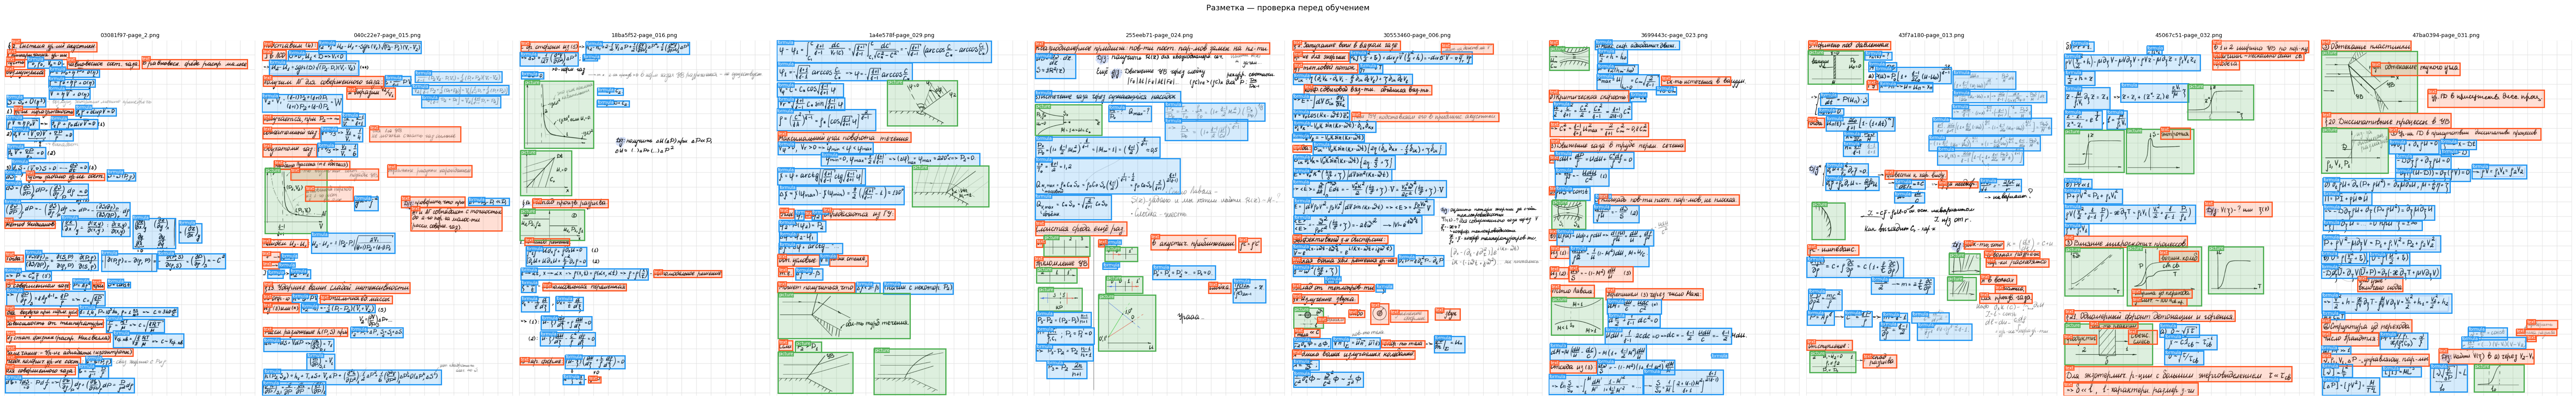

In [6]:
def show_labels(img_path, lbl_path, ax=None):
    img = Image.open(img_path)
    W, H = img.size
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 11))
    ax.imshow(img); ax.axis("off")
    ax.set_title(img_path.name, fontsize=9)
    for line in lbl_path.read_text().splitlines():
        p = line.strip().split()
        if len(p) < 5: continue
        cls = int(p[0])
        xc, yc, w, h = map(float, p[1:5])
        x0, y0 = (xc - w/2)*W, (yc - h/2)*H
        color = CLASS_COLORS[cls % len(CLASS_COLORS)]
        ax.add_patch(mpatches.Rectangle(
            (x0, y0), w*W, h*H,
            linewidth=2, edgecolor=color, facecolor=color+"30"))
        ax.text(x0+3, y0+14, CLASS_NAMES[cls], fontsize=7, color="white",
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor="none"))

cols = min(len(pairs), 10)
fig, axes = plt.subplots(1, cols, figsize=(6*cols, 10))
if cols == 1: axes = [axes]
for ax, (img_path, lbl_path) in zip(axes, pairs[:cols]):
    show_labels(img_path, lbl_path, ax)
plt.suptitle("Разметка — проверка перед обучением", fontsize=13)
plt.tight_layout()
plt.show()